Dataset shape: (100000, 19)

First few rows:
   Magnetic Field Fluctuations   Leakage  Instabilities  Plasma Instabilities  \
0                     0.037454  0.058078       0.028259              0.015705   
1                     0.095071  0.052697       0.045868              0.009551   
2                     0.073199  0.035104       0.009922              0.013794   
3                     0.059866  0.049321       0.044684              0.047349   
4                     0.015602  0.036510       0.020308              0.088453   

   Magnetic Field Strength Magnetic Field Configuration  Injection Energy  \
0                 9.000578                      tokamak          5.713125   
1                 3.841421         reversed field pinch          9.819548   
2                 1.467187                  stellarator          7.016781   
3                 9.277696                      tokamak          4.018930   
4                 4.926347         reversed field pinch          6.145836   

   Be

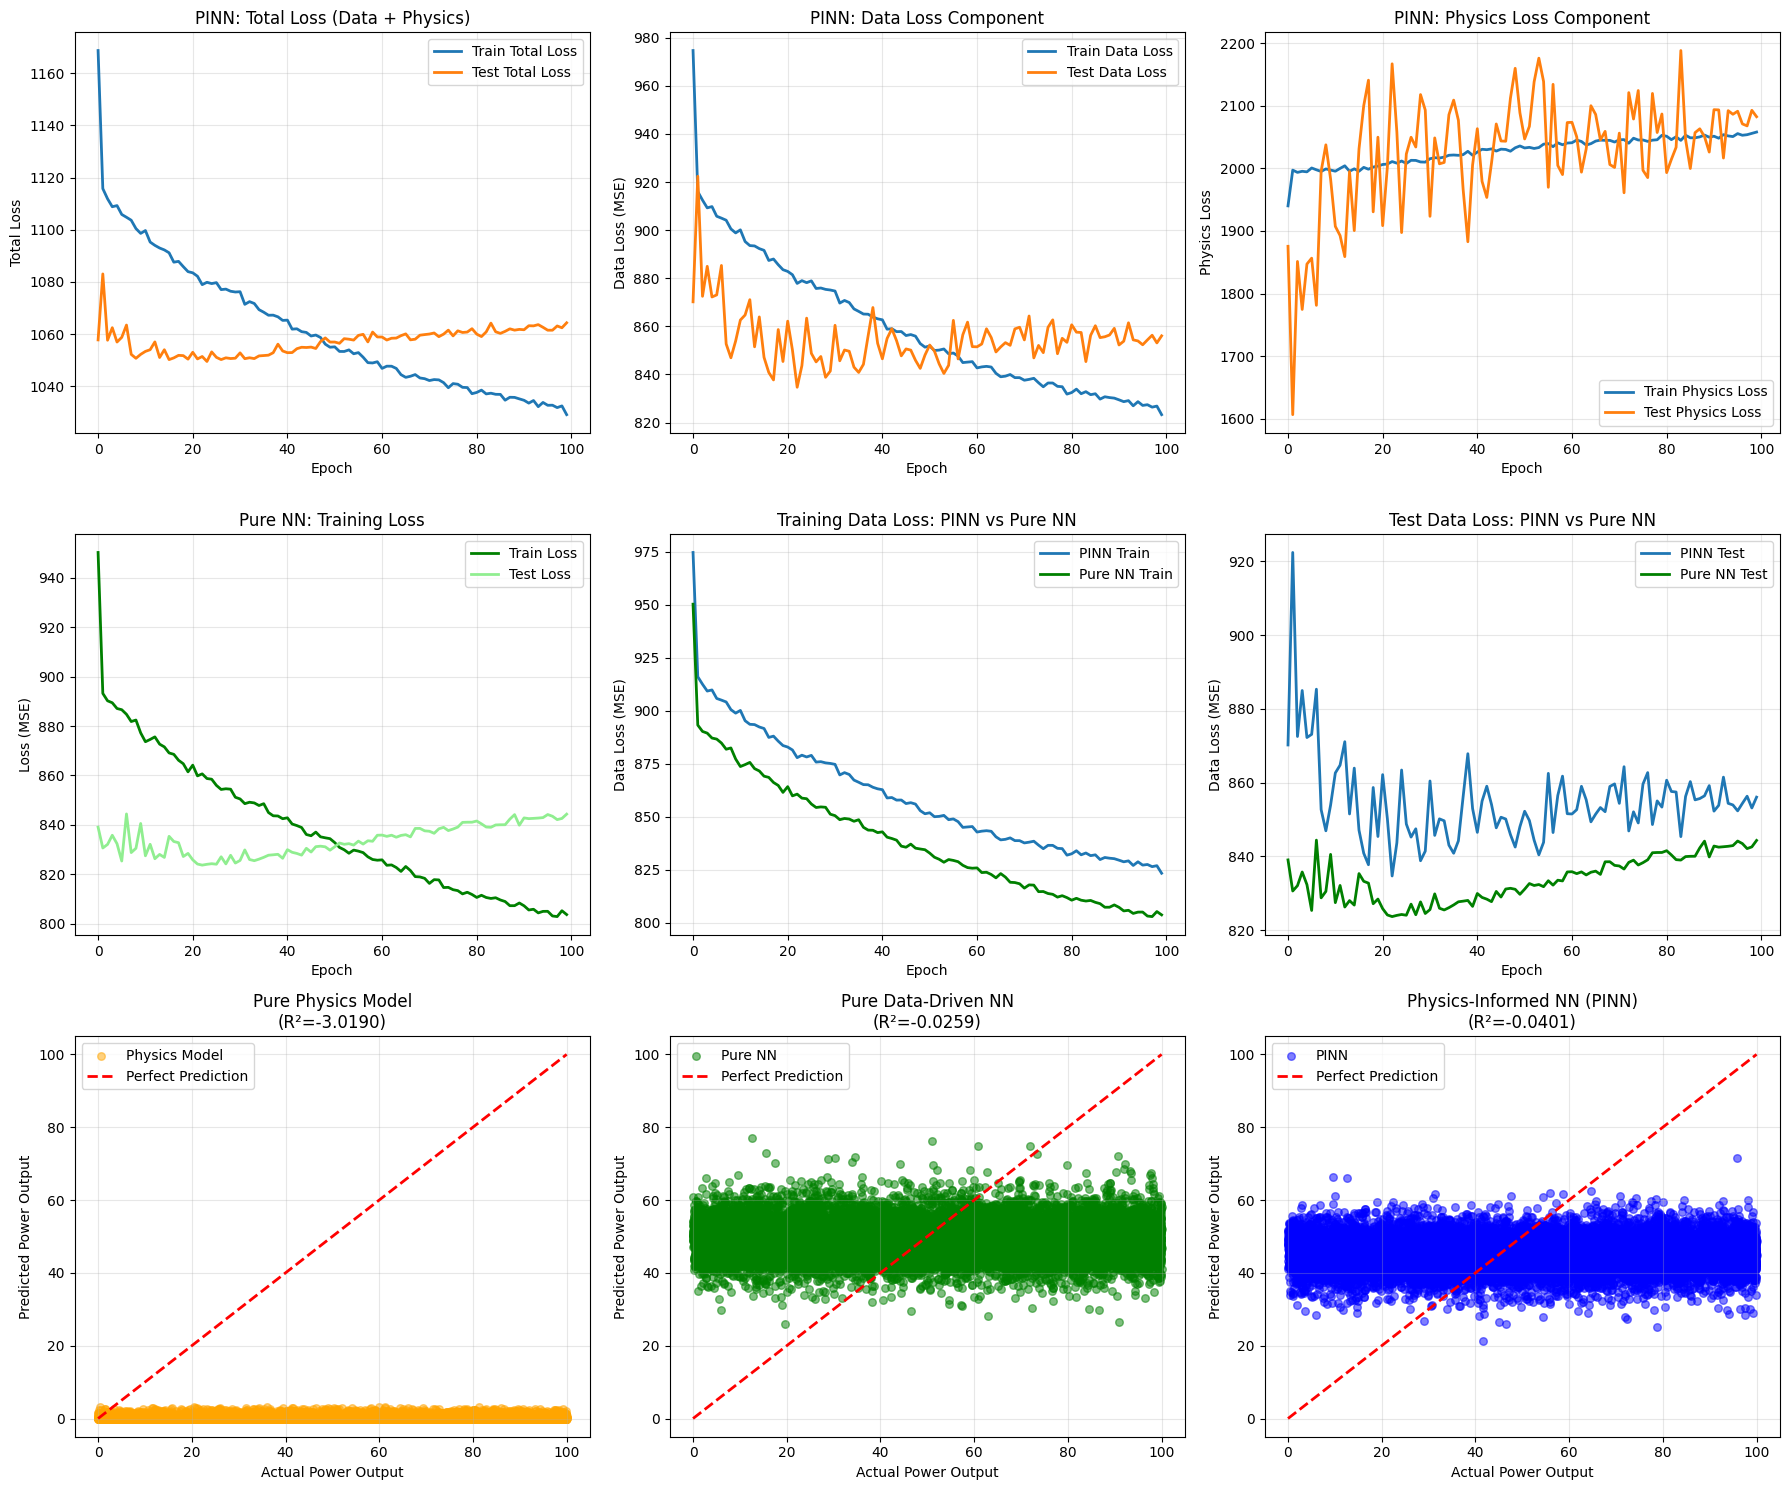

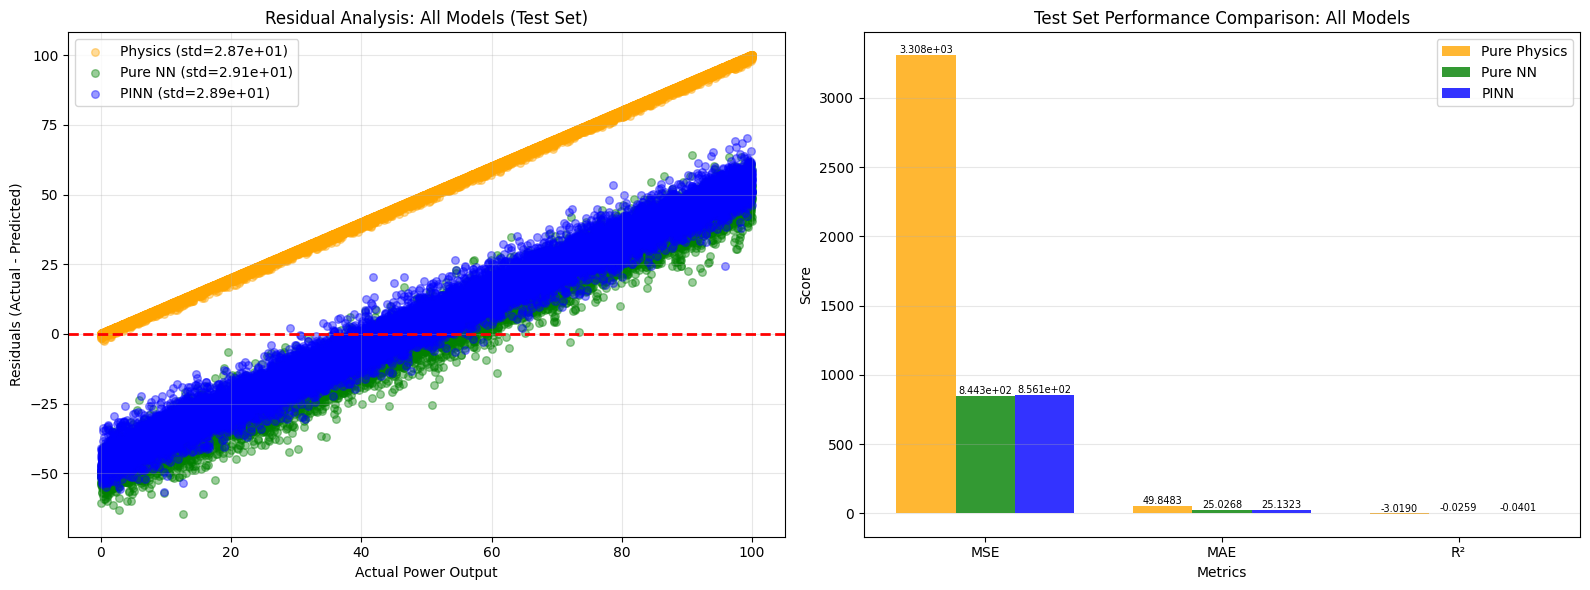


EXPERIMENT SUMMARY

Physics Parameters (from regression):
  β_scaled = 1.000000e+00
  β_original = 1.000000e-53
  b = 20.000000

Scaling Factors:
  Temperature scale: 1.00e+08
  Density scale: 1.00e+19
  Power scale: 1.00e+01

PINN Configuration:
  Physics weight (λ) = 0.1
  Architecture: 22 -> 128 -> 64 -> 32 -> 1
  Training epochs: 100
  Features: 16 numeric + 2 categorical (one-hot encoded)

To change physics weight, modify the PHYSICS_WEIGHT variable in SECTION 11


In [ ]:
# -*- coding: utf-8 -*-
"""PINN for Nuclear Fusion Power Output with Physics-Based Loss

This implementation:
1. Fits regression to find physics parameters β and b
2. Implements PINN with data loss + physics loss
3. Allows tunable hyperparameter for physics loss weight
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# SECTION 1: Load and Prepare Data
# =========================
DATA_PATH = "/content/fusion_experiment.csv"  # Update this path as needed

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# =========================
# SECTION 2: Extract relevant features for physics model
# =========================
# We need Temperature and Plasma Density for physics regression
temperature = df['Temperature'].values  # T
plasma_density = df['Fuel Density'].values  # n (using Fuel Density as plasma density)
power_output = df['Power Output'].values  # P

# Remove any NaN values
mask = ~(np.isnan(temperature) | np.isnan(plasma_density) | np.isnan(power_output))
temperature_clean = temperature[mask]
plasma_density_clean = plasma_density[mask]
power_output_clean = power_output[mask]

print(f"\nData points for physics regression: {len(temperature_clean)}")
print(f"Temperature range: [{temperature_clean.min():.2e}, {temperature_clean.max():.2e}]")
print(f"Plasma Density range: [{plasma_density_clean.min():.2e}, {plasma_density_clean.max():.2e}]")
print(f"Power Output range: [{power_output_clean.min():.2e}, {power_output_clean.max():.2e}]")

# =========================
# SECTION 3: Fit Physics Model to Find β and b (with proper scaling)
# =========================
# Scale down Temperature and Density to prevent overflow
# Following the pattern from your original code
T_scale = 1e8  # Scale temperature to ~1-10 range
n_scale = 1e19  # Scale density to ~1-100 range
P_scale = 1e1   # Scale power output

temperature_scaled = temperature_clean / T_scale
plasma_density_scaled = plasma_density_clean / n_scale
power_output_scaled = power_output_clean / P_scale

print(f"\nScaled Temperature range: [{temperature_scaled.min():.2f}, {temperature_scaled.max():.2f}]")
print(f"Scaled Plasma Density range: [{plasma_density_scaled.min():.2f}, {plasma_density_scaled.max():.2f}]")
print(f"Scaled Power Output range: [{power_output_scaled.min():.2f}, {power_output_scaled.max():.2f}]")

def physics_model_scaled(X, beta, b):
    """
    P(n,T) = β * φ(T) * n²
    where φ(T) = T² * exp(-b/√T)

    Working with scaled values to prevent overflow
    X is a 2D array where X[:, 0] = T_scaled and X[:, 1] = n_scaled
    """
    T = X[:, 0]
    n = X[:, 1]

    # Compute phi(T)
    sqrt_T = np.sqrt(np.maximum(T, 1e-10))
    phi_T = T**2 * np.exp(-b / sqrt_T)

    P = beta * phi_T * n**2

    return P

# Prepare data for curve fitting
X_physics_scaled = np.column_stack([temperature_scaled, plasma_density_scaled])

# Initial guess for scaled parameters
p0 = [1.0, 20.0]  # [beta, b]

print(f"\nInitial parameter guess: β={p0[0]:.6e}, b={p0[1]}")

# Fit the model
try:
    popt, pcov = curve_fit(
        physics_model_scaled,
        X_physics_scaled.T,
        power_output_scaled,
        p0=p0,
        maxfev=10000
    )
    beta_fit_scaled, b_fit = popt

    # Convert beta back to original scale
    # P_original = P_scale * β_scaled * φ(T_scaled) * n_scaled²
    # P_original = P_scale * β_scaled * (T_scaled² * exp(-b/√T_scaled)) * n_scaled²
    # We want: P_original = β_original * φ(T_original) * n_original²
    # β_original = β_scaled * P_scale / (T_scale² * n_scale²)
    beta_fit = beta_fit_scaled * P_scale / (T_scale**2 * n_scale**2)

    print("\n" + "="*50)
    print("PHYSICS PARAMETER FITTING RESULTS")
    print("="*50)
    print(f"β (beta) scaled = {beta_fit_scaled:.6e}")
    print(f"β (beta) original scale = {beta_fit:.6e}")
    print(f"b = {b_fit:.6f}")

    # Calculate R² for the physics model (on scaled data)
    P_physics_pred_scaled = physics_model_scaled(X_physics_scaled.T, beta_fit_scaled, b_fit)
    r2_physics = r2_score(power_output_scaled, P_physics_pred_scaled)
    mse_physics = mean_squared_error(power_output_scaled, P_physics_pred_scaled)

    print(f"\nPhysics Model Performance (scaled):")
    print(f"R² Score: {r2_physics:.4f}")
    print(f"MSE: {mse_physics:.4e}")
    print("="*50)

except Exception as e:
    print(f"Error in curve fitting: {e}")
    # Use default values if fitting fails
    beta_fit_scaled = 1.0
    b_fit = 20.0
    beta_fit = beta_fit_scaled * P_scale / (T_scale**2 * n_scale**2)
    print(f"Using default values: β_scaled={beta_fit_scaled:.6e}, b={b_fit}")

# Store scaling factors for later use
scaling_factors = {
    'T_scale': T_scale,
    'n_scale': n_scale,
    'P_scale': P_scale,
    'beta_scaled': beta_fit_scaled
}

# =========================
# SECTION 4: Prepare Full Dataset for PINN with OneHotEncoding
# =========================
target_col = "Power Output"
y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric columns: {len(num_cols)}")
print(f"Categorical columns: {cat_cols}")

# Handle NaN values
for col in num_cols:
    X[col] = X[col].fillna(X[col].mean())

for col in cat_cols:
    mode_val = X[col].mode()[0] if not X[col].mode().empty else "Unknown"
    X[col] = X[col].fillna(mode_val)

y = y.fillna(y.mean())

# =========================
# SECTION 5: Create Preprocessor with OneHotEncoding
# =========================
# Scale numeric columns
numeric_tf = Pipeline([
    ("scaler", StandardScaler())
])

# Encode categorical columns
categorical_tf = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both transformers
preprocessor = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])

# =========================
# SECTION 6: Train/Test split and transformation
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Fit on train data and transform both train and test sets
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f"\nX_train_t shape: {X_train_t.shape}")
print(f"X_test_t shape: {X_test_t.shape}")

# Build feature names
feature_names = num_cols.copy()
if len(cat_cols) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    feature_names += ohe.get_feature_names_out(cat_cols).tolist()

print(f"Total features after encoding: {len(feature_names)}")

# Get indices for Temperature and Fuel Density in transformed data
temp_idx = num_cols.index('Temperature')
density_idx = num_cols.index('Fuel Density')

print(f"\nFeature indices - Temperature: {temp_idx}, Fuel Density: {density_idx}")

# Get the scaler for inverse transformation
num_scaler = preprocessor.named_transformers_["num"].named_steps["scaler"]

# =========================
# SECTION 7: Define PINN Architecture
# =========================
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.2):
        super(PINN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =========================
# SECTION 8: Physics Loss Function (with proper scaling)
# =========================
def compute_physics_loss(model, X_batch, temp_idx, density_idx, beta_scaled, b, num_scaler, scaling_factors):
    """
    Compute physics-informed loss based on P(n,T) = β * φ(T) * n²
    where φ(T) = T² * exp(-b/√T)

    Uses scaled values to prevent overflow
    """
    # Get predictions from model
    P_pred = model(X_batch).squeeze()

    # Extract Temperature and Density (only the numeric features need unscaling)
    X_numeric_scaled = X_batch[:, :len(num_cols)].detach().cpu().numpy()
    X_numeric_unscaled = num_scaler.inverse_transform(X_numeric_scaled)

    T = X_numeric_unscaled[:, temp_idx]
    n = X_numeric_unscaled[:, density_idx]

    # Scale down to prevent overflow
    T_scaled = T / scaling_factors['T_scale']
    n_scaled = n / scaling_factors['n_scale']

    # Compute physics-based power using scaled values
    sqrt_T = np.sqrt(np.maximum(T_scaled, 1e-10))
    phi_T = T_scaled**2 * np.exp(-b / sqrt_T)
    P_physics_scaled = beta_scaled * phi_T * n_scaled**2

    # Scale back to original power output scale
    P_physics = P_physics_scaled * scaling_factors['P_scale']

    # Convert to torch tensor
    P_physics_tensor = torch.tensor(P_physics, dtype=torch.float32, device=X_batch.device)

    # Physics loss (MSE between predicted and physics-based power)
    physics_loss = torch.mean((P_pred - P_physics_tensor)**2)

    return physics_loss

# =========================
# SECTION 9: Training Function
# =========================
def train_pinn(model, train_loader, test_loader,
               temp_idx, density_idx, beta_scaled, b,
               num_scaler, scaling_factors,
               physics_weight=0.1,
               epochs=100, lr=0.001):
    """
    Train PINN with combined data loss and physics loss

    Total Loss = Data Loss + physics_weight * Physics Loss
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {
        'train_loss': [], 'train_data_loss': [], 'train_physics_loss': [],
        'test_loss': [], 'test_data_loss': [], 'test_physics_loss': []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        train_data_losses = []
        train_physics_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            y_pred = model(X_batch).squeeze()

            # Data loss
            data_loss = criterion(y_pred, y_batch)

            # Physics loss
            physics_loss = compute_physics_loss(
                model, X_batch, temp_idx, density_idx,
                beta_scaled, b, num_scaler, scaling_factors
            )

            # Total loss
            total_loss = data_loss + physics_weight * physics_loss

            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            train_losses.append(total_loss.item())
            train_data_losses.append(data_loss.item())
            train_physics_losses.append(physics_loss.item())

        # Validation
        model.eval()
        test_losses = []
        test_data_losses = []
        test_physics_losses = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch).squeeze()
                data_loss = criterion(y_pred, y_batch)

                physics_loss = compute_physics_loss(
                    model, X_batch, temp_idx, density_idx,
                    beta_scaled, b, num_scaler, scaling_factors
                )

                total_loss = data_loss + physics_weight * physics_loss

                test_losses.append(total_loss.item())
                test_data_losses.append(data_loss.item())
                test_physics_losses.append(physics_loss.item())

        # Record history
        history['train_loss'].append(np.mean(train_losses))
        history['train_data_loss'].append(np.mean(train_data_losses))
        history['train_physics_loss'].append(np.mean(train_physics_losses))
        history['test_loss'].append(np.mean(test_losses))
        history['test_data_loss'].append(np.mean(test_data_losses))
        history['test_physics_loss'].append(np.mean(test_physics_losses))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train - Total: {history['train_loss'][-1]:.4f}, "
                  f"Data: {history['train_data_loss'][-1]:.4f}, "
                  f"Physics: {history['train_physics_loss'][-1]:.4e}")
            print(f"  Test  - Total: {history['test_loss'][-1]:.4f}, "
                  f"Data: {history['test_data_loss'][-1]:.4f}, "
                  f"Physics: {history['test_physics_loss'][-1]:.4e}")

    return history

# =========================
# SECTION 10: Prepare data loaders
# =========================
# No scaling for target since we're predicting actual values
X_train_tensor = torch.tensor(X_train_t, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_t, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# =========================
# SECTION 11: Initialize and Train Models (PINN + Pure Data-Driven NN)
# =========================
input_dim = X_train_t.shape[1]
pinn_model = PINN(input_dim, hidden_dims=[128, 64, 32], dropout=0.2)
pure_nn_model = PINN(input_dim, hidden_dims=[128, 64, 32], dropout=0.2)  # Same architecture

print("\n" + "="*50)
print("TRAINING MODELS")
print("="*50)

# Train with physics weight = 0.1 (you can change this)
PHYSICS_WEIGHT = 0.1  # <-- CHANGE THIS VALUE TO TUNE PHYSICS LOSS CONTRIBUTION

# ===== Train PINN =====
print("\n>>> Training Physics-Informed Neural Network (PINN)")
print(f"    Physics weight (λ): {PHYSICS_WEIGHT}")
print(f"    Using β_scaled = {beta_fit_scaled:.6e}, b = {b_fit:.6f}")
print(f"    Using β_original = {beta_fit:.6e}")
print("="*50 + "\n")

pinn_history = train_pinn(
    pinn_model, train_loader, test_loader,
    temp_idx, density_idx, beta_fit_scaled, b_fit,
    num_scaler, scaling_factors,
    physics_weight=PHYSICS_WEIGHT,
    epochs=100,
    lr=0.001
)

# ===== Train Pure Data-Driven NN =====
print("\n>>> Training Pure Data-Driven Neural Network")
print("    Physics weight (λ): 0.0 (no physics loss)")
print("="*50 + "\n")

pure_nn_history = train_pinn(
    pure_nn_model, train_loader, test_loader,
    temp_idx, density_idx, beta_fit_scaled, b_fit,
    num_scaler, scaling_factors,
    physics_weight=0.0,  # No physics loss - pure data-driven
    epochs=100,
    lr=0.001
)

# =========================
# SECTION 12: Evaluate All Models and Compare
# =========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# PINN predictions
pinn_model.eval()
with torch.no_grad():
    y_train_pred_pinn = pinn_model(X_train_tensor.to(device)).cpu().numpy().ravel()
    y_test_pred_pinn = pinn_model(X_test_tensor.to(device)).cpu().numpy().ravel()

# Pure NN predictions
pure_nn_model.eval()
with torch.no_grad():
    y_train_pred_nn = pure_nn_model(X_train_tensor.to(device)).cpu().numpy().ravel()
    y_test_pred_nn = pure_nn_model(X_test_tensor.to(device)).cpu().numpy().ravel()

y_train_actual = y_train.values
y_test_actual = y_test.values

# Get predictions from pure physics model (using scaled calculations)
X_train_numeric = num_scaler.inverse_transform(X_train_t[:, :len(num_cols)])
X_test_numeric = num_scaler.inverse_transform(X_test_t[:, :len(num_cols)])

T_train = X_train_numeric[:, temp_idx]
n_train = X_train_numeric[:, density_idx]
T_test = X_test_numeric[:, temp_idx]
n_test = X_test_numeric[:, density_idx]

# Scale down for computation
T_train_scaled = T_train / scaling_factors['T_scale']
n_train_scaled = n_train / scaling_factors['n_scale']
T_test_scaled = T_test / scaling_factors['T_scale']
n_test_scaled = n_test / scaling_factors['n_scale']

# Pure physics model predictions using scaled values
sqrt_T_train = np.sqrt(np.maximum(T_train_scaled, 1e-10))
phi_T_train = T_train_scaled**2 * np.exp(-b_fit / sqrt_T_train)
y_train_pred_physics_scaled = beta_fit_scaled * phi_T_train * n_train_scaled**2
y_train_pred_physics = y_train_pred_physics_scaled * scaling_factors['P_scale']

sqrt_T_test = np.sqrt(np.maximum(T_test_scaled, 1e-10))
phi_T_test = T_test_scaled**2 * np.exp(-b_fit / sqrt_T_test)
y_test_pred_physics_scaled = beta_fit_scaled * phi_T_test * n_test_scaled**2
y_test_pred_physics = y_test_pred_physics_scaled * scaling_factors['P_scale']

# Calculate metrics for all models
print("\n" + "="*80)
print("MODEL COMPARISON: PINN vs PURE NN vs PURE PHYSICS MODEL")
print("="*80)

print("\n" + "-"*80)
print("1. PURE PHYSICS MODEL (Regression Only)")
print("-"*80)
print("\nTraining Set:")
print(f"  MSE: {mean_squared_error(y_train_actual, y_train_pred_physics):.4e}")
print(f"  MAE: {mean_absolute_error(y_train_actual, y_train_pred_physics):.4e}")
print(f"  R²:  {r2_score(y_train_actual, y_train_pred_physics):.4f}")

print("\nTest Set:")
print(f"  MSE: {mean_squared_error(y_test_actual, y_test_pred_physics):.4e}")
print(f"  MAE: {mean_absolute_error(y_test_actual, y_test_pred_physics):.4e}")
print(f"  R²:  {r2_score(y_test_actual, y_test_pred_physics):.4f}")

print("\n" + "-"*80)
print("2. PURE DATA-DRIVEN NEURAL NETWORK (No Physics)")
print("-"*80)
print("\nTraining Set:")
print(f"  MSE: {mean_squared_error(y_train_actual, y_train_pred_nn):.4e}")
print(f"  MAE: {mean_absolute_error(y_train_actual, y_train_pred_nn):.4e}")
print(f"  R²:  {r2_score(y_train_actual, y_train_pred_nn):.4f}")

print("\nTest Set:")
print(f"  MSE: {mean_squared_error(y_test_actual, y_test_pred_nn):.4e}")
print(f"  MAE: {mean_absolute_error(y_test_actual, y_test_pred_nn):.4e}")
print(f"  R²:  {r2_score(y_test_actual, y_test_pred_nn):.4f}")

print("\n" + "-"*80)
print("3. PHYSICS-INFORMED NEURAL NETWORK (PINN)")
print("-"*80)
print("\nTraining Set:")
print(f"  MSE: {mean_squared_error(y_train_actual, y_train_pred_pinn):.4e}")
print(f"  MAE: {mean_absolute_error(y_train_actual, y_train_pred_pinn):.4e}")
print(f"  R²:  {r2_score(y_train_actual, y_train_pred_pinn):.4f}")

print("\nTest Set:")
print(f"  MSE: {mean_squared_error(y_test_actual, y_test_pred_pinn):.4e}")
print(f"  MAE: {mean_absolute_error(y_test_actual, y_test_pred_pinn):.4e}")
print(f"  R²:  {r2_score(y_test_actual, y_test_pred_pinn):.4f}")

# Calculate improvements
test_mse_physics = mean_squared_error(y_test_actual, y_test_pred_physics)
test_mse_nn = mean_squared_error(y_test_actual, y_test_pred_nn)
test_mse_pinn = mean_squared_error(y_test_actual, y_test_pred_pinn)

test_r2_physics = r2_score(y_test_actual, y_test_pred_physics)
test_r2_nn = r2_score(y_test_actual, y_test_pred_nn)
test_r2_pinn = r2_score(y_test_actual, y_test_pred_pinn)

print("\n" + "-"*80)
print("PERFORMANCE SUMMARY (Test Set)")
print("-"*80)

# Find best model
best_mse = min(test_mse_physics, test_mse_nn, test_mse_pinn)
best_r2 = max(test_r2_physics, test_r2_nn, test_r2_pinn)

model_names = ['Physics Model', 'Pure NN', 'PINN']
mse_values = [test_mse_physics, test_mse_nn, test_mse_pinn]
r2_values = [test_r2_physics, test_r2_nn, test_r2_pinn]

best_mse_model = model_names[mse_values.index(best_mse)]
best_r2_model = model_names[r2_values.index(best_r2)]

print(f"\nBest MSE: {best_mse:.4e} ({best_mse_model})")
print(f"Best R²:  {best_r2:.4f} ({best_r2_model})")

print("\nMSE Rankings (lower is better):")
sorted_mse = sorted(zip(model_names, mse_values), key=lambda x: x[1])
for i, (name, mse) in enumerate(sorted_mse, 1):
    print(f"  {i}. {name}: {mse:.4e}")

print("\nR² Rankings (higher is better):")
sorted_r2 = sorted(zip(model_names, r2_values), key=lambda x: x[1], reverse=True)
for i, (name, r2) in enumerate(sorted_r2, 1):
    print(f"  {i}. {name}: {r2:.4f}")

print("="*80)

# =========================
# SECTION 13: Comprehensive Visualization with All Three Models
# =========================
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Row 1: Training histories for PINN
axes[0, 0].plot(pinn_history['train_loss'], label='Train Total Loss', linewidth=2)
axes[0, 0].plot(pinn_history['test_loss'], label='Test Total Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('PINN: Total Loss (Data + Physics)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(pinn_history['train_data_loss'], label='Train Data Loss', linewidth=2)
axes[0, 1].plot(pinn_history['test_data_loss'], label='Test Data Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Data Loss (MSE)')
axes[0, 1].set_title('PINN: Data Loss Component')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(pinn_history['train_physics_loss'], label='Train Physics Loss', linewidth=2)
axes[0, 2].plot(pinn_history['test_physics_loss'], label='Test Physics Loss', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Physics Loss')
axes[0, 2].set_title('PINN: Physics Loss Component')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Training history for Pure NN
axes[1, 0].plot(pure_nn_history['train_loss'], label='Train Loss', linewidth=2, color='green')
axes[1, 0].plot(pure_nn_history['test_loss'], label='Test Loss', linewidth=2, color='lightgreen')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss (MSE)')
axes[1, 0].set_title('Pure NN: Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Compare data loss between PINN and Pure NN
axes[1, 1].plot(pinn_history['train_data_loss'], label='PINN Train', linewidth=2)
axes[1, 1].plot(pure_nn_history['train_data_loss'], label='Pure NN Train', linewidth=2, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Data Loss (MSE)')
axes[1, 1].set_title('Training Data Loss: PINN vs Pure NN')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(pinn_history['test_data_loss'], label='PINN Test', linewidth=2)
axes[1, 2].plot(pure_nn_history['test_data_loss'], label='Pure NN Test', linewidth=2, color='green')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Data Loss (MSE)')
axes[1, 2].set_title('Test Data Loss: PINN vs Pure NN')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Row 3: Predicted vs Actual for all three models
axes[2, 0].scatter(y_test_actual, y_test_pred_physics, alpha=0.5, s=30,
                   color='orange', label='Physics Model')
axes[2, 0].plot([y_test_actual.min(), y_test_actual.max()],
                [y_test_actual.min(), y_test_actual.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[2, 0].set_xlabel('Actual Power Output')
axes[2, 0].set_ylabel('Predicted Power Output')
axes[2, 0].set_title(f'Pure Physics Model\n(R²={r2_score(y_test_actual, y_test_pred_physics):.4f})')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].scatter(y_test_actual, y_test_pred_nn, alpha=0.5, s=30,
                   color='green', label='Pure NN')
axes[2, 1].plot([y_test_actual.min(), y_test_actual.max()],
                [y_test_actual.min(), y_test_actual.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[2, 1].set_xlabel('Actual Power Output')
axes[2, 1].set_ylabel('Predicted Power Output')
axes[2, 1].set_title(f'Pure Data-Driven NN\n(R²={r2_score(y_test_actual, y_test_pred_nn):.4f})')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].scatter(y_test_actual, y_test_pred_pinn, alpha=0.5, s=30,
                   color='blue', label='PINN')
axes[2, 2].plot([y_test_actual.min(), y_test_actual.max()],
                [y_test_actual.min(), y_test_actual.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[2, 2].set_xlabel('Actual Power Output')
axes[2, 2].set_ylabel('Predicted Power Output')
axes[2, 2].set_title(f'Physics-Informed NN (PINN)\n(R²={r2_score(y_test_actual, y_test_pred_pinn):.4f})')
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional comparison plots
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residual comparison for all models
residuals_physics = y_test_actual - y_test_pred_physics
residuals_nn = y_test_actual - y_test_pred_nn
residuals_pinn = y_test_actual - y_test_pred_pinn

axes2[0].scatter(y_test_actual, residuals_physics, alpha=0.4, s=30,
                 label=f'Physics (std={np.std(residuals_physics):.2e})', color='orange')
axes2[0].scatter(y_test_actual, residuals_nn, alpha=0.4, s=30,
                 label=f'Pure NN (std={np.std(residuals_nn):.2e})', color='green')
axes2[0].scatter(y_test_actual, residuals_pinn, alpha=0.4, s=30,
                 label=f'PINN (std={np.std(residuals_pinn):.2e})', color='blue')
axes2[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes2[0].set_xlabel('Actual Power Output')
axes2[0].set_ylabel('Residuals (Actual - Predicted)')
axes2[0].set_title('Residual Analysis: All Models (Test Set)')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Plot 2: Bar chart comparison
metrics = ['MSE', 'MAE', 'R²']
physics_scores = [
    mean_squared_error(y_test_actual, y_test_pred_physics),
    mean_absolute_error(y_test_actual, y_test_pred_physics),
    r2_score(y_test_actual, y_test_pred_physics)
]
nn_scores = [
    mean_squared_error(y_test_actual, y_test_pred_nn),
    mean_absolute_error(y_test_actual, y_test_pred_nn),
    r2_score(y_test_actual, y_test_pred_nn)
]
pinn_scores = [
    mean_squared_error(y_test_actual, y_test_pred_pinn),
    mean_absolute_error(y_test_actual, y_test_pred_pinn),
    r2_score(y_test_actual, y_test_pred_pinn)
]

x = np.arange(len(metrics))
width = 0.25

bars1 = axes2[1].bar(x - width, physics_scores, width, label='Pure Physics',
                     color='orange', alpha=0.8)
bars2 = axes2[1].bar(x, nn_scores, width, label='Pure NN',
                     color='green', alpha=0.8)
bars3 = axes2[1].bar(x + width, pinn_scores, width, label='PINN',
                     color='blue', alpha=0.8)

axes2[1].set_xlabel('Metrics')
axes2[1].set_ylabel('Score')
axes2[1].set_title('Test Set Performance Comparison: All Models')
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(metrics)
axes2[1].legend()
axes2[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes2[1].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3e}' if abs(height) > 100 else f'{height:.4f}',
                      ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

# =========================
# SECTION 14: Summary
# =========================
print("\n" + "="*50)
print("EXPERIMENT SUMMARY")
print("="*50)
print(f"\nPhysics Parameters (from regression):")
print(f"  β_scaled = {beta_fit_scaled:.6e}")
print(f"  β_original = {beta_fit:.6e}")
print(f"  b = {b_fit:.6f}")
print(f"\nScaling Factors:")
print(f"  Temperature scale: {scaling_factors['T_scale']:.2e}")
print(f"  Density scale: {scaling_factors['n_scale']:.2e}")
print(f"  Power scale: {scaling_factors['P_scale']:.2e}")
print(f"\nPINN Configuration:")
print(f"  Physics weight (λ) = {PHYSICS_WEIGHT}")
print(f"  Architecture: {input_dim} -> 128 -> 64 -> 32 -> 1")
print(f"  Training epochs: 100")
print(f"  Features: {len(num_cols)} numeric + {len(cat_cols)} categorical (one-hot encoded)")
print(f"\nTo change physics weight, modify the PHYSICS_WEIGHT variable in SECTION 11")
print("="*50)

In [ ]:
# """ Our PINN Implementation:

# 1. Fits regression to find physics parameters β and b
# 2. Implements PINN with data loss + physics loss
# 3. Implements NN with purely data loss (zero physics loss)

# Later we compare the results from all these implementations
# """

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.optimize import curve_fit

# import torch
# import torch.nn as nn
# from torch.utils.data import TensorDataset, DataLoader

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# # =========================
# # SECTION 1: Load and Prepare Data
# # =========================
# DATA_PATH = "/content/fusion_experiment.csv"

# df = pd.read_csv(DATA_PATH)
# df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# print("Dataset shape:", df.shape)
# print("\nFirst few rows:")
# print(df.head())

Dataset shape: (100000, 19)

First few rows:
   Magnetic Field Fluctuations   Leakage  Instabilities  Plasma Instabilities  \
0                     0.037454  0.058078       0.028259              0.015705   
1                     0.095071  0.052697       0.045868              0.009551   
2                     0.073199  0.035104       0.009922              0.013794   
3                     0.059866  0.049321       0.044684              0.047349   
4                     0.015602  0.036510       0.020308              0.088453   

   Magnetic Field Strength Magnetic Field Configuration  Injection Energy  \
0                 9.000578                      tokamak          5.713125   
1                 3.841421         reversed field pinch          9.819548   
2                 1.467187                  stellarator          7.016781   
3                 9.277696                      tokamak          4.018930   
4                 4.926347         reversed field pinch          6.145836   

   Be

In [ ]:
# # =========================
# # SECTION 2: Extract relevant features for physics model
# # =========================
# # We need Temperature and Plasma Density for physics regression
# temperature = df['Temperature'].values  # T
# plasma_density = df['Fuel Density'].values  # n (using Fuel Density as plasma density)
# power_output = df['Power Output'].values  # P

# # Remove any NaN values
# mask = ~(np.isnan(temperature) | np.isnan(plasma_density) | np.isnan(power_output))
# temperature_clean = temperature[mask]
# plasma_density_clean = plasma_density[mask]
# power_output_clean = power_output[mask]

# print(f"\nData points for physics regression: {len(temperature_clean)}")
# print(f"Temperature range: [{temperature_clean.min():.2e}, {temperature_clean.max():.2e}]")
# print(f"Plasma Density range: [{plasma_density_clean.min():.2e}, {plasma_density_clean.max():.2e}]")
# print(f"Power Output range: [{power_output_clean.min():.2e}, {power_output_clean.max():.2e}]")


Data points for physics regression: 100000
Temperature range: [1.00e+08, 5.00e+08]
Plasma Density range: [1.00e+19, 1.00e+20]
Power Output range: [3.77e-05, 1.00e+02]


In [ ]:
# # =========================
# # SECTION 4: Prepare Full Dataset for PINN with OneHotEncoding
# # =========================
# target_col = "Power Output"
# y = df[target_col].copy()
# X = df.drop(columns=[target_col]).copy()

# # Identify numeric and categorical columns
# num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# print(f"\nNumeric columns: {len(num_cols)}")
# print(f"Categorical columns: {cat_cols}")

# # Handle NaN values
# for col in num_cols:
#     X[col] = X[col].fillna(X[col].mean())

# for col in cat_cols:
#     mode_val = X[col].mode()[0] if not X[col].mode().empty else "Unknown"
#     X[col] = X[col].fillna(mode_val)

# y = y.fillna(y.mean())


Numeric columns: 16
Categorical columns: ['Magnetic Field Configuration', 'Target Composition']


In [ ]:
# # =========================
# # SECTION 5: Create Preprocessor with OneHotEncoding
# # =========================
# # Scale numeric columns
# numeric_tf = Pipeline([
#     ("scaler", StandardScaler())
# ])

# # Encode categorical columns
# categorical_tf = Pipeline([
#     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
# ])

# # Combine both transformers
# preprocessor = ColumnTransformer([
#     ("num", numeric_tf, num_cols),
#     ("cat", categorical_tf, cat_cols)
# ])

In [ ]:
# # =========================
# # SECTION 6: Train/Test split and transformation
# # =========================
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42
# )

# # Fit on train data and transform both train and test sets
# X_train_t = preprocessor.fit_transform(X_train)
# X_test_t = preprocessor.transform(X_test)

# print(f"\nX_train_t shape: {X_train_t.shape}")
# print(f"X_test_t shape: {X_test_t.shape}")

# # Build feature names
# feature_names = num_cols.copy()
# if len(cat_cols) > 0:
#     ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
#     feature_names += ohe.get_feature_names_out(cat_cols).tolist()

# print(f"Total features after encoding: {len(feature_names)}")

# # Get indices for Temperature and Fuel Density in transformed data
# temp_idx = num_cols.index('Temperature')
# density_idx = num_cols.index('Fuel Density')

# print(f"\nFeature indices - Temperature: {temp_idx}, Fuel Density: {density_idx}")

# # Get the scaler for inverse transformation
# num_scaler = preprocessor.named_transformers_["num"].named_steps["scaler"]


X_train_t shape: (80000, 22)
X_test_t shape: (20000, 22)
Total features after encoding: 22

Feature indices - Temperature: 9, Fuel Density: 8


In [ ]:
# # =========================
# # SECTION 7: Define PINN Architecture
# # =========================
# class PINN(nn.Module):
#     def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.2):
#         super(PINN, self).__init__()

#         layers = []
#         prev_dim = input_dim

#         for hidden_dim in hidden_dims:
#             layers.append(nn.Linear(prev_dim, hidden_dim))
#             layers.append(nn.ReLU())
#             layers.append(nn.Dropout(dropout))
#             prev_dim = hidden_dim

#         layers.append(nn.Linear(prev_dim, 1))

#         self.network = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.network(x)

In [ ]:
# # =========================
# # SECTION 8: Physics Loss Function (with proper scaling)
# # =========================
# def compute_physics_loss(model, X_batch, temp_idx, density_idx, beta_scaled, b, num_scaler, scaling_factors):
#     """
#     Compute physics-informed loss based on P(n,T) = β * φ(T) * n²
#     where φ(T) = T² * exp(-b/√T)

#     Uses scaled values to prevent overflow
#     """
#     # Get predictions from model
#     P_pred = model(X_batch).squeeze()

#     # Extract Temperature and Density (only the numeric features need unscaling)
#     X_numeric_scaled = X_batch[:, :len(num_cols)].detach().cpu().numpy()
#     X_numeric_unscaled = num_scaler.inverse_transform(X_numeric_scaled)

#     T = X_numeric_unscaled[:, temp_idx]
#     n = X_numeric_unscaled[:, density_idx]

#     # Scale down to prevent overflow
#     T_scaled = T / scaling_factors['T_scale']
#     n_scaled = n / scaling_factors['n_scale']

#     # Compute physics-based power using scaled values
#     sqrt_T = np.sqrt(np.maximum(T_scaled, 1e-10))
#     phi_T = T_scaled**2 * np.exp(-b / sqrt_T)
#     P_physics_scaled = beta_scaled * phi_T * n_scaled**2

#     # Scale back to original power output scale
#     P_physics = P_physics_scaled * scaling_factors['P_scale']

#     # Convert to torch tensor
#     P_physics_tensor = torch.tensor(P_physics, dtype=torch.float32, device=X_batch.device)

#     # Physics loss (MSE between predicted and physics-based power)
#     physics_loss = torch.mean((P_pred - P_physics_tensor)**2)

#     return physics_loss

In [ ]:
# # =========================
# # SECTION 9: Training Function
# # =========================
# def train_pinn(model, train_loader, test_loader,
#                temp_idx, density_idx, beta_scaled, b,
#                num_scaler, scaling_factors,
#                physics_weight=0.1,
#                epochs=100, lr=0.001):
#     """
#     Train PINN with combined data loss and physics loss

#     Total Loss = Data Loss + physics_weight * Physics Loss
#     """
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model = model.to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     history = {
#         'train_loss': [], 'train_data_loss': [], 'train_physics_loss': [],
#         'test_loss': [], 'test_data_loss': [], 'test_physics_loss': []
#     }

#     for epoch in range(epochs):
#         # Training
#         model.train()
#         train_losses = []
#         train_data_losses = []
#         train_physics_losses = []

#         for X_batch, y_batch in train_loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             # Forward pass
#             y_pred = model(X_batch).squeeze()

#             # Data loss
#             data_loss = criterion(y_pred, y_batch)

#             # Physics loss
#             physics_loss = compute_physics_loss(
#                 model, X_batch, temp_idx, density_idx,
#                 beta_scaled, b, num_scaler, scaling_factors
#             )

#             # Total loss
#             total_loss = data_loss + physics_weight * physics_loss

#             # Backward pass
#             optimizer.zero_grad()
#             total_loss.backward()
#             optimizer.step()

#             train_losses.append(total_loss.item())
#             train_data_losses.append(data_loss.item())
#             train_physics_losses.append(physics_loss.item())

#         # Validation
#         model.eval()
#         test_losses = []
#         test_data_losses = []
#         test_physics_losses = []

#         with torch.no_grad():
#             for X_batch, y_batch in test_loader:
#                 X_batch = X_batch.to(device)
#                 y_batch = y_batch.to(device)

#                 y_pred = model(X_batch).squeeze()
#                 data_loss = criterion(y_pred, y_batch)

#                 physics_loss = compute_physics_loss(
#                     model, X_batch, temp_idx, density_idx,
#                     beta_scaled, b, num_scaler, scaling_factors
#                 )

#                 total_loss = data_loss + physics_weight * physics_loss

#                 test_losses.append(total_loss.item())
#                 test_data_losses.append(data_loss.item())
#                 test_physics_losses.append(physics_loss.item())

#         # Record history
#         history['train_loss'].append(np.mean(train_losses))
#         history['train_data_loss'].append(np.mean(train_data_losses))
#         history['train_physics_loss'].append(np.mean(train_physics_losses))
#         history['test_loss'].append(np.mean(test_losses))
#         history['test_data_loss'].append(np.mean(test_data_losses))
#         history['test_physics_loss'].append(np.mean(test_physics_losses))

#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch [{epoch+1}/{epochs}]")
#             print(f"  Train - Total: {history['train_loss'][-1]:.4f}, "
#                   f"Data: {history['train_data_loss'][-1]:.4f}, "
#                   f"Physics: {history['train_physics_loss'][-1]:.4e}")
#             print(f"  Test  - Total: {history['test_loss'][-1]:.4f}, "
#                   f"Data: {history['test_data_loss'][-1]:.4f}, "
#                   f"Physics: {history['test_physics_loss'][-1]:.4e}")

#     return history

In [ ]:
# # =========================
# # SECTION 10: Prepare data loaders
# # =========================
# # No scaling for target since we're predicting actual values
# X_train_tensor = torch.tensor(X_train_t, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
# X_test_tensor = torch.tensor(X_test_t, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# # =========================
# # SECTION 11: Initialize and Train Models (PINN + Pure Data-Driven NN)
# # =========================
# input_dim = X_train_t.shape[1]
# pinn_model = PINN(input_dim, hidden_dims=[128, 64, 32], dropout=0.2)
# pure_nn_model = PINN(input_dim, hidden_dims=[128, 64, 32], dropout=0.2)  # Same architecture

# print("\n" + "="*50)
# print("TRAINING MODELS")
# print("="*50)

# # Train with physics weight = 0.1 (you can change this)
# PHYSICS_WEIGHT = 0.1  # <-- CHANGE THIS VALUE TO TUNE PHYSICS LOSS CONTRIBUTION

# # ===== Train PINN =====
# print("\n>>> Training Physics-Informed Neural Network (PINN)")
# print(f"    Physics weight (λ): {PHYSICS_WEIGHT}")
# print(f"    Using β_scaled = {beta_fit_scaled:.6e}, b = {b_fit:.6f}")
# print(f"    Using β_original = {beta_fit:.6e}")
# print("="*50 + "\n")

# pinn_history = train_pinn(
#     pinn_model, train_loader, test_loader,
#     temp_idx, density_idx, beta_fit_scaled, b_fit,
#     num_scaler, scaling_factors,
#     physics_weight=PHYSICS_WEIGHT,
#     epochs=100,
#     lr=0.001
# )

# # ===== Train Pure Data-Driven NN =====
# print("\n>>> Training Pure Data-Driven Neural Network")
# print("    Physics weight (λ): 0.0 (no physics loss)")
# print("="*50 + "\n")

# pure_nn_history = train_pinn(
#     pure_nn_model, train_loader, test_loader,
#     temp_idx, density_idx, beta_fit_scaled, b_fit,
#     num_scaler, scaling_factors,
#     physics_weight=0.0,  # No physics loss - pure data-driven
#     epochs=100,
#     lr=0.001
# )


TRAINING MODELS

>>> Training Physics-Informed Neural Network (PINN)
    Physics weight (λ): 0.1


NameError: name 'beta_fit_scaled' is not defined

In [ ]:
# # =========================
# # SECTION 13: Comprehensive Visualization with All Three Models
# # =========================
# fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# # Row 1: Training histories for PINN
# axes[0, 0].plot(pinn_history['train_loss'], label='Train Total Loss', linewidth=2)
# axes[0, 0].plot(pinn_history['test_loss'], label='Test Total Loss', linewidth=2)
# axes[0, 0].set_xlabel('Epoch')
# axes[0, 0].set_ylabel('Total Loss')
# axes[0, 0].set_title('PINN: Total Loss (Data + Physics)')
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(pinn_history['train_data_loss'], label='Train Data Loss', linewidth=2)
# axes[0, 1].plot(pinn_history['test_data_loss'], label='Test Data Loss', linewidth=2)
# axes[0, 1].set_xlabel('Epoch')
# axes[0, 1].set_ylabel('Data Loss (MSE)')
# axes[0, 1].set_title('PINN: Data Loss Component')
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# axes[0, 2].plot(pinn_history['train_physics_loss'], label='Train Physics Loss', linewidth=2)
# axes[0, 2].plot(pinn_history['test_physics_loss'], label='Test Physics Loss', linewidth=2)
# axes[0, 2].set_xlabel('Epoch')
# axes[0, 2].set_ylabel('Physics Loss')
# axes[0, 2].set_title('PINN: Physics Loss Component')
# axes[0, 2].legend()
# axes[0, 2].grid(True, alpha=0.3)

# # Row 2: Training history for Pure NN
# axes[1, 0].plot(pure_nn_history['train_loss'], label='Train Loss', linewidth=2, color='green')
# axes[1, 0].plot(pure_nn_history['test_loss'], label='Test Loss', linewidth=2, color='lightgreen')
# axes[1, 0].set_xlabel('Epoch')
# axes[1, 0].set_ylabel('Loss (MSE)')
# axes[1, 0].set_title('Pure NN: Training Loss')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # Compare data loss between PINN and Pure NN
# axes[1, 1].plot(pinn_history['train_data_loss'], label='PINN Train', linewidth=2)
# axes[1, 1].plot(pure_nn_history['train_data_loss'], label='Pure NN Train', linewidth=2, color='green')
# axes[1, 1].set_xlabel('Epoch')
# axes[1, 1].set_ylabel('Data Loss (MSE)')
# axes[1, 1].set_title('Training Data Loss: PINN vs Pure NN')
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

# axes[1, 2].plot(pinn_history['test_data_loss'], label='PINN Test', linewidth=2)
# axes[1, 2].plot(pure_nn_history['test_data_loss'], label='Pure NN Test', linewidth=2, color='green')
# axes[1, 2].set_xlabel('Epoch')
# axes[1, 2].set_ylabel('Data Loss (MSE)')
# axes[1, 2].set_title('Test Data Loss: PINN vs Pure NN')
# axes[1, 2].legend()
# axes[1, 2].grid(True, alpha=0.3)

# # Row 3: Predicted vs Actual for all three models
# axes[2, 0].scatter(y_test_actual, y_test_pred_physics, alpha=0.5, s=30,
#                    color='orange', label='Physics Model')
# axes[2, 0].plot([y_test_actual.min(), y_test_actual.max()],
#                 [y_test_actual.min(), y_test_actual.max()],
#                 'r--', linewidth=2, label='Perfect Prediction')
# axes[2, 0].set_xlabel('Actual Power Output')
# axes[2, 0].set_ylabel('Predicted Power Output')
# axes[2, 0].set_title(f'Pure Physics Model\n(R²={r2_score(y_test_actual, y_test_pred_physics):.4f})')
# axes[2, 0].legend()
# axes[2, 0].grid(True, alpha=0.3)

# axes[2, 1].scatter(y_test_actual, y_test_pred_nn, alpha=0.5, s=30,
#                    color='green', label='Pure NN')
# axes[2, 1].plot([y_test_actual.min(), y_test_actual.max()],
#                 [y_test_actual.min(), y_test_actual.max()],
#                 'r--', linewidth=2, label='Perfect Prediction')
# axes[2, 1].set_xlabel('Actual Power Output')
# axes[2, 1].set_ylabel('Predicted Power Output')
# axes[2, 1].set_title(f'Pure Data-Driven NN\n(R²={r2_score(y_test_actual, y_test_pred_nn):.4f})')
# axes[2, 1].legend()
# axes[2, 1].grid(True, alpha=0.3)

# axes[2, 2].scatter(y_test_actual, y_test_pred_pinn, alpha=0.5, s=30,
#                    color='blue', label='PINN')
# axes[2, 2].plot([y_test_actual.min(), y_test_actual.max()],
#                 [y_test_actual.min(), y_test_actual.max()],
#                 'r--', linewidth=2, label='Perfect Prediction')
# axes[2, 2].set_xlabel('Actual Power Output')
# axes[2, 2].set_ylabel('Predicted Power Output')
# axes[2, 2].set_title(f'Physics-Informed NN (PINN)\n(R²={r2_score(y_test_actual, y_test_pred_pinn):.4f})')
# axes[2, 2].legend()
# axes[2, 2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Additional comparison plots
# fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# # Plot 1: Residual comparison for all models
# residuals_physics = y_test_actual - y_test_pred_physics
# residuals_nn = y_test_actual - y_test_pred_nn
# residuals_pinn = y_test_actual - y_test_pred_pinn

# axes2[0].scatter(y_test_actual, residuals_physics, alpha=0.4, s=30,
#                  label=f'Physics (std={np.std(residuals_physics):.2e})', color='orange')
# axes2[0].scatter(y_test_actual, residuals_nn, alpha=0.4, s=30,
#                  label=f'Pure NN (std={np.std(residuals_nn):.2e})', color='green')
# axes2[0].scatter(y_test_actual, residuals_pinn, alpha=0.4, s=30,
#                  label=f'PINN (std={np.std(residuals_pinn):.2e})', color='blue')
# axes2[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
# axes2[0].set_xlabel('Actual Power Output')
# axes2[0].set_ylabel('Residuals (Actual - Predicted)')
# axes2[0].set_title('Residual Analysis: All Models (Test Set)')
# axes2[0].legend()
# axes2[0].grid(True, alpha=0.3)

# # Plot 2: Bar chart comparison
# metrics = ['MSE', 'MAE', 'R²']
# physics_scores = [
#     mean_squared_error(y_test_actual, y_test_pred_physics),
#     mean_absolute_error(y_test_actual, y_test_pred_physics),
#     r2_score(y_test_actual, y_test_pred_physics)
# ]
# nn_scores = [
#     mean_squared_error(y_test_actual, y_test_pred_nn),
#     mean_absolute_error(y_test_actual, y_test_pred_nn),
#     r2_score(y_test_actual, y_test_pred_nn)
# ]
# pinn_scores = [
#     mean_squared_error(y_test_actual, y_test_pred_pinn),
#     mean_absolute_error(y_test_actual, y_test_pred_pinn),
#     r2_score(y_test_actual, y_test_pred_pinn)
# ]

# x = np.arange(len(metrics))
# width = 0.25

# bars1 = axes2[1].bar(x - width, physics_scores, width, label='Pure Physics',
#                      color='orange', alpha=0.8)
# bars2 = axes2[1].bar(x, nn_scores, width, label='Pure NN',
#                      color='green', alpha=0.8)
# bars3 = axes2[1].bar(x + width, pinn_scores, width, label='PINN',
#                      color='blue', alpha=0.8)

# axes2[1].set_xlabel('Metrics')
# axes2[1].set_ylabel('Score')
# axes2[1].set_title('Test Set Performance Comparison: All Models')
# axes2[1].set_xticks(x)
# axes2[1].set_xticklabels(metrics)
# axes2[1].legend()
# axes2[1].grid(True, alpha=0.3, axis='y')

# # Add value labels on bars
# for bars in [bars1, bars2, bars3]:
#     for bar in bars:
#         height = bar.get_height()
#         axes2[1].text(bar.get_x() + bar.get_width()/2., height,
#                       f'{height:.3e}' if abs(height) > 100 else f'{height:.4f}',
#                       ha='center', va='bottom', fontsize=7)

# plt.tight_layout()
# plt.show()

In [ ]:
# # =========================
# # SECTION 14: Summary
# # =========================
# print("\n" + "="*50)
# print("EXPERIMENT SUMMARY")
# print("="*50)
# print(f"\nPhysics Parameters (from regression):")
# print(f"  β_scaled = {beta_fit_scaled:.6e}")
# print(f"  β_original = {beta_fit:.6e}")
# print(f"  b = {b_fit:.6f}")
# print(f"\nScaling Factors:")
# print(f"  Temperature scale: {scaling_factors['T_scale']:.2e}")
# print(f"  Density scale: {scaling_factors['n_scale']:.2e}")
# print(f"  Power scale: {scaling_factors['P_scale']:.2e}")
# print(f"\nPINN Configuration:")
# print(f"  Physics weight (λ) = {PHYSICS_WEIGHT}")
# print(f"  Architecture: {input_dim} -> 128 -> 64 -> 32 -> 1")
# print(f"  Training epochs: 100")
# print(f"  Features: {len(num_cols)} numeric + {len(cat_cols)} categorical (one-hot encoded)")
# print(f"\nTo change physics weight, modify the PHYSICS_WEIGHT variable in SECTION 11")
# print("="*50)